# Analytical and Numerical Methods for the Black-Scholes Equation in European Option Pricing

**Authors:**

* Jakub Ciągło (275986)
* Piotr Czech (276014)
* Mateusz Ćwiek (276011)
___

In [17]:
from pathlib import Path
import sys

sys.dont_write_bytecode = True


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import numpy as np
import pandas as pd

from black_scholes_pde import (
    BlackScholesParams,
    GridParams,
    black_scholes_price,
    convergence_table,
    error_metrics,
    solve_explicit_fd,
)
from black_scholes_pde.visualization import plot_error, plot_price_comparison

In this section, we compute one sample price of a European call option. We choose the Black-Scholes model parameters and the finite difference grid, solve the PDE numerically, and compare the result with the exact Black-Scholes formula.


In [18]:
params = BlackScholesParams(strike=100, maturity=1, rate=0.05, volatility=0.1, option_type="put")
grid = GridParams(s_max=200, asset_steps=200, time_steps=2000)

asset_grid, numerical = solve_explicit_fd(params, grid)
exact = black_scholes_price(asset_grid, params)

error_metrics(numerical, exact)

{'max_abs_error': 0.005616558657201232,
 'mae': 0.000604935515074113,
 'rmse': 0.0014587882158639185}

Next, we plot two price curves: the exact analytical solution and the numerical finite difference solution. The second plot shows the absolute error as a function of the underlying asset price.

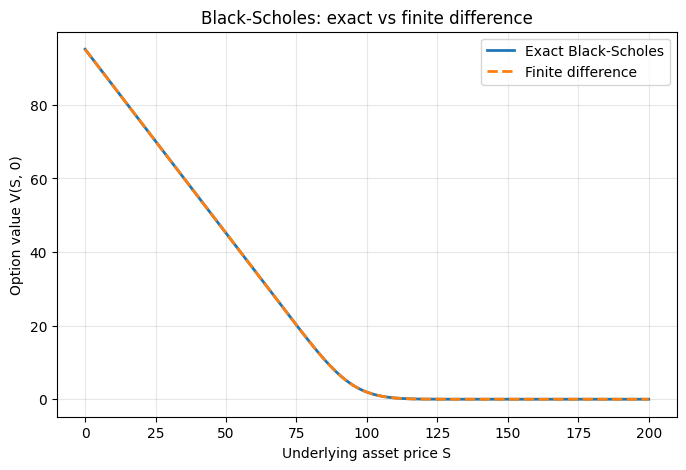

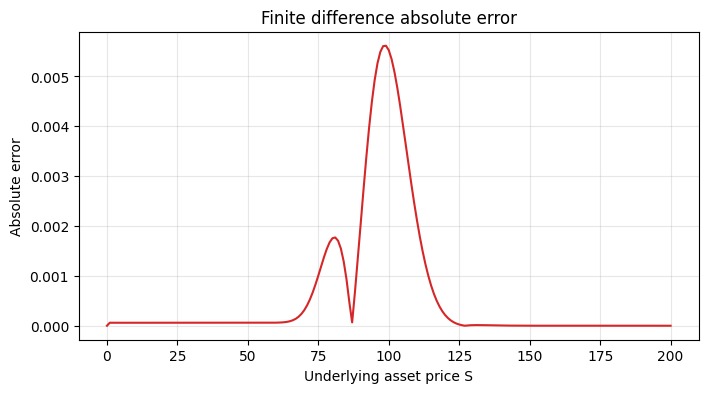

In [19]:
plot_price_comparison(asset_grid, numerical, exact)
plot_error(asset_grid, numerical, exact);

Finally, we check how the numerical error changes when the grid is refined. For several pairs of asset and time step counts, we solve the PDE again and compare the numerical result with the exact price."

In [20]:
convergence_table(
    params,
    grid_sizes=[(50, 500), (100, 1000), (200, 2000), (400, 8000)],
)

,asset_steps,time_steps,max_abs_error,mae,rmse
0,50,500,0.089337,0.009028,0.023006
1,100,1000,0.022329,0.002319,0.005758
2,200,2000,0.005617,0.000605,0.001459
3,400,8000,0.001404,0.000152,0.000365
